In [24]:
# Cell 1: Import libraries

import os
import time
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# NTHU-DDD Driver Drowsiness Detection — EfficientNetB0 + FastKAN

Notebook này được chuyển từ hướng TensorFlow/Xception sang **PyTorch EfficientNetB0_FastKAN** cho dataset NTHU-DDD Multi-Class.

Cấu trúc dataset được hỗ trợ:

```text
/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train/
├── drowsy/
│   ├── sleepyCombination/
│   ├── slowBlinkWithNodding/
│   └── yawning/
└── notdrowsy/
```

Bài toán đang triển khai theo **4 lớp**:

```text
0: notdrowsy
1: sleepyCombination
2: slowBlinkWithNodding
3: yawning
```

In [25]:
# Cell 2: Seed and device

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("SEED:", SEED)
print("Device:", device)

SEED: 42
Device: cuda


In [26]:
# Cell 3: Dataset path

from pathlib import Path

DATA_DIR = Path("/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train")

if not DATA_DIR.exists():
    print("Không tìm thấy path mặc định. Các folder cấp 1 trong /kaggle/input:")
    for p in Path("/kaggle/input").iterdir():
        if p.is_dir():
            print(p)

    raise FileNotFoundError(f"Không tìm thấy dataset tại: {DATA_DIR}")

drowsy_dir = DATA_DIR / "drowsy"
notdrowsy_dir = DATA_DIR / "notdrowsy"

sleepy_dir = drowsy_dir / "sleepyCombination"
slowblink_dir = drowsy_dir / "slowBlinkWithNodding"
yawning_dir = drowsy_dir / "yawning"

required_dirs = [
    drowsy_dir,
    sleepy_dir,
    slowblink_dir,
    yawning_dir,
    notdrowsy_dir
]

for folder in required_dirs:
    if not folder.exists():
        raise FileNotFoundError(f"Không tìm thấy folder: {folder}")

print("DATA_DIR:", DATA_DIR)

print("\nFolder structure:")
for folder in required_dirs:
    print(folder)

DATA_DIR: /kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train

Folder structure:
/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train/drowsy
/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train/drowsy/sleepyCombination
/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train/drowsy/slowBlinkWithNodding
/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train/drowsy/yawning
/kaggle/input/nthu-dataset-ddd-multi-class/Multi class/train/notdrowsy


In [27]:
# Cell 4: Class labels

class_names = [
    "notdrowsy",
    "sleepyCombination",
    "slowBlinkWithNodding",
    "yawning"
]

class_to_idx = {
    "notdrowsy": 0,
    "sleepyCombination": 1,
    "slowBlinkWithNodding": 2,
    "yawning": 3
}

idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_names)

print("Class mapping:")
for name, idx in class_to_idx.items():
    print(f"{idx}: {name}")

Class mapping:
0: notdrowsy
1: sleepyCombination
2: slowBlinkWithNodding
3: yawning


In [28]:
# Cell 5: Collect image paths from nested NTHU-DDD folders

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_images_from_folder(folder, label):
    samples = []

    for img_path in folder.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            samples.append((img_path, label))

    return samples


def collect_nthu_samples(root_dir):
    root_dir = Path(root_dir)
    samples = []

    # notdrowsy
    notdrowsy_dir = root_dir / "notdrowsy"
    if not notdrowsy_dir.exists():
        raise FileNotFoundError(f"Không thấy folder: {notdrowsy_dir}")

    samples.extend(
        collect_images_from_folder(
            notdrowsy_dir,
            class_to_idx["notdrowsy"]
        )
    )

    # drowsy subclasses
    drowsy_root = root_dir / "drowsy"
    if not drowsy_root.exists():
        raise FileNotFoundError(f"Không thấy folder: {drowsy_root}")

    for sub_class in ["sleepyCombination", "slowBlinkWithNodding", "yawning"]:
        sub_dir = drowsy_root / sub_class

        if not sub_dir.exists():
            raise FileNotFoundError(f"Không thấy folder: {sub_dir}")

        samples.extend(
            collect_images_from_folder(
                sub_dir,
                class_to_idx[sub_class]
            )
        )

    return samples


all_samples = collect_nthu_samples(DATA_DIR)
all_labels = [label for _, label in all_samples]

print("Total images:", len(all_samples))
print("Class counts:")

for class_id, count in sorted(Counter(all_labels).items()):
    print(f"{class_id} - {idx_to_class[class_id]}: {count}")

Total images: 66521
Class counts:
0 - notdrowsy: 30491
1 - sleepyCombination: 17756
2 - slowBlinkWithNodding: 9412
3 - yawning: 8862


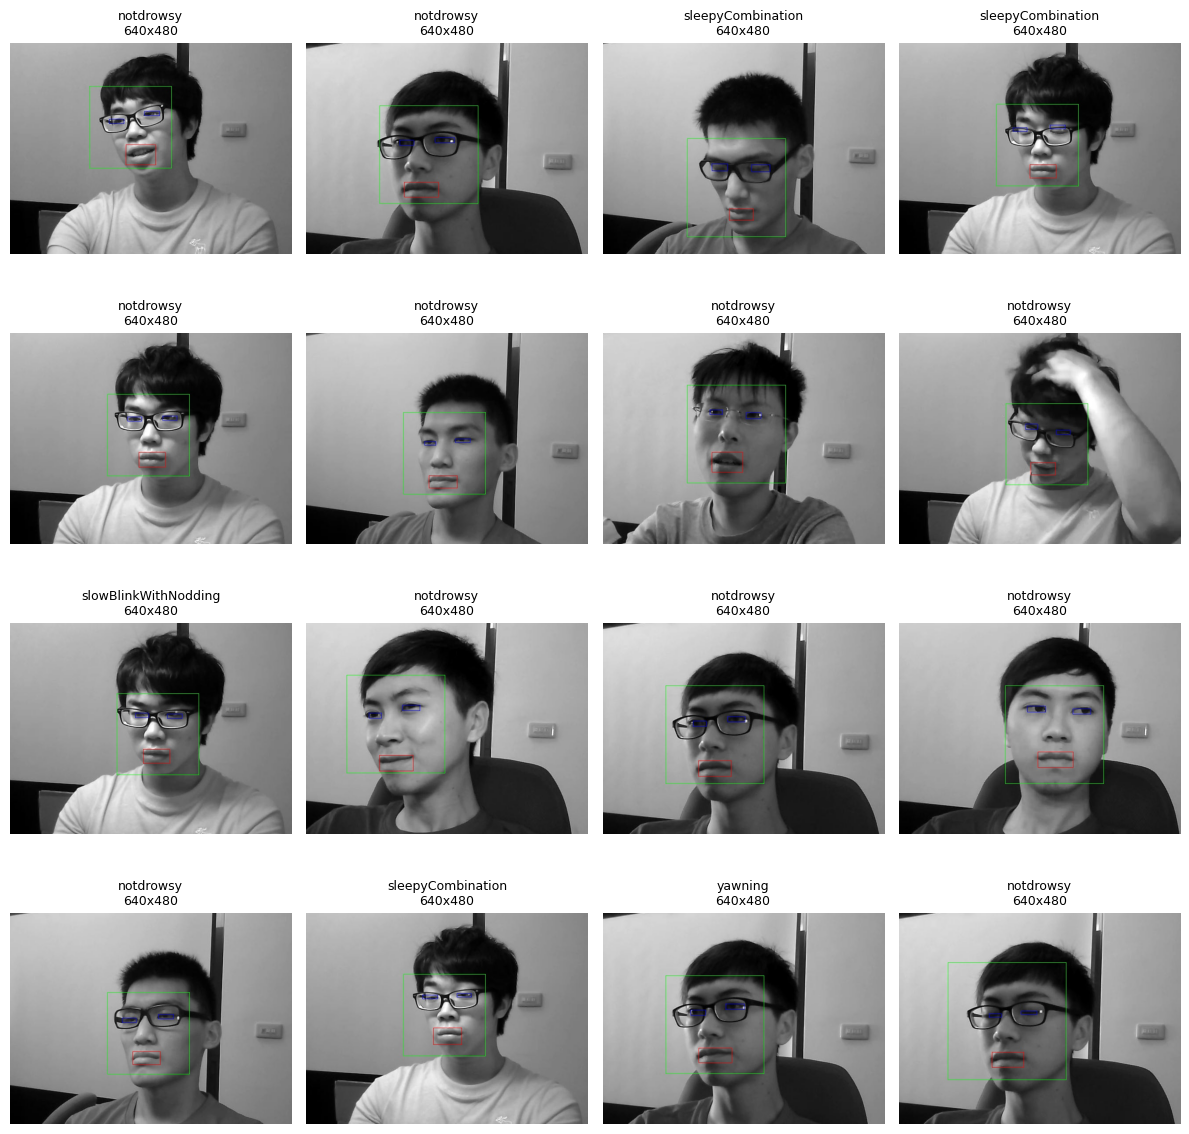

In [29]:
# Cell 6: Visualize sample images

sample_images = random.sample(all_samples, min(16, len(all_samples)))

plt.figure(figsize=(12, 12))

for i, (img_path, label) in enumerate(sample_images, start=1):
    img = Image.open(img_path).convert("RGB")

    plt.subplot(4, 4, i)
    plt.imshow(img)
    plt.title(
        f"{idx_to_class[label]}\n{img.size[0]}x{img.size[1]}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# Cell 7: Train/Validation/Test split

labels = [label for _, label in all_samples]

train_samples, temp_samples = train_test_split(
    all_samples,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

temp_labels = [label for _, label in temp_samples]

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))

print("\nTrain counts:")
for class_id, count in sorted(Counter([y for _, y in train_samples]).items()):
    print(f"{idx_to_class[class_id]}: {count}")

print("\nVal counts:")
for class_id, count in sorted(Counter([y for _, y in val_samples]).items()):
    print(f"{idx_to_class[class_id]}: {count}")

print("\nTest counts:")
for class_id, count in sorted(Counter([y for _, y in test_samples]).items()):
    print(f"{idx_to_class[class_id]}: {count}")

Train: 46564
Val: 9978
Test: 9979

Train counts:
notdrowsy: 21344
sleepyCombination: 12429
slowBlinkWithNodding: 6588
yawning: 6203

Val counts:
notdrowsy: 4573
sleepyCombination: 2663
slowBlinkWithNodding: 1412
yawning: 1330

Test counts:
notdrowsy: 4574
sleepyCombination: 2664
slowBlinkWithNodding: 1412
yawning: 1329


In [31]:
# Cell 8: Custom Dataset and DataLoader

class NTHUDDDDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = NTHUDDDDataset(train_samples, transform=train_transform)
val_dataset = NTHUDDDDataset(val_samples, transform=eval_transform)
test_dataset = NTHUDDDDataset(test_samples, transform=eval_transform)

train_labels = [label for _, label in train_samples]
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)

print("Class counts:", class_counts)

class_weights_sampler = 1.0 / class_counts
sample_weights = [class_weights_sampler[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)
print("Device:", device)

Class counts: [21344 12429  6588  6203]
Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])
Device: cuda


In [ ]:
# Cell 9: Define EfficientNetB0_FastKAN model

from torchvision import models
import torch
import torch.nn as nn
import torch.nn.functional as F


class FastKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, grid_size=8, sigma=0.5):
        super().__init__()

        self.sigma = sigma

        grid = torch.linspace(-1, 1, grid_size)
        self.register_buffer("grid", grid)

        self.base = nn.Linear(input_dim, output_dim)

        self.spline_weight = nn.Parameter(
            torch.randn(output_dim, input_dim, grid_size) * 0.01
        )

    def forward(self, x):
        base_out = self.base(x)

        x_expanded = x.unsqueeze(-1)

        rbf = torch.exp(
            -((x_expanded - self.grid) ** 2) / (2 * self.sigma ** 2)
        )

        spline_out = torch.einsum(
            "big,oig->bo",
            rbf,
            self.spline_weight
        )

        return base_out + spline_out


class FastKAN(nn.Module):
    def __init__(self, layers_hidden, grid_size=8, sigma=0.5, dropout=0.5):
        super().__init__()

        self.layers = nn.ModuleList()

        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers.append(
                FastKANLayer(
                    input_dim=in_dim,
                    output_dim=out_dim,
                    grid_size=grid_size,
                    sigma=sigma
                )
            )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer(x)
            x = F.silu(x)
            x = self.dropout(x)

        return self.layers[-1](x)


class EfficientNetB0_FastKAN(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()

        if pretrained:
            weights = models.EfficientNet_B0_Weights.DEFAULT
        else:
            weights = None

        backbone = models.efficientnet_b0(weights=weights)
        self.features = backbone.features
        
        # (batch_size, 1280, 7, 7)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # EfficientNet-B0 output feature dim = 1280
        self.feature_dim = 1280

        self.fastkan = FastKAN(
            layers_hidden=[self.feature_dim, 512, 128, num_classes],
            grid_size=8,
            sigma=0.5,
            dropout=0.5
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fastkan(x)

        return x

model_effb0_fastkan = EfficientNetB0_FastKAN(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(device)

print(model_effb0_fastkan)

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out = model_effb0_fastkan(dummy)

print("Dummy input:", dummy.shape)
print("Dummy output:", out.shape)

EfficientNetB0_FastKAN(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dN

In [33]:
# Cell 10: Model parameters

def print_parameters(model, model_name="Model", verbose=False):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if verbose:
        print(f"\n{'='*20} [{model_name} Layer Details] {'='*20}")
        print(f"{'Layer Name':<50} | {'Shape':<25} | {'Parameters':<15}")
        print("-" * 100)

        for name, param in model.named_parameters():
            if param.requires_grad:
                print(
                    f"{name:<50} | "
                    f"{str(list(param.shape)):<25} | "
                    f"{param.numel():>15,}"
                )

        print("-" * 100)

    print(f"[{model_name}] Total Trainable Params: {total_params:,}")
    return total_params


print_parameters(model_effb0_fastkan, "EfficientNetB0_FastKAN", verbose=False)

[EfficientNetB0_FastKAN] Total Trainable Params: 10,500,864


10500864

In [34]:
# Cell 11: Train function

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    model_name,
    scheduler=None,
    print_every=100
):
    model.to(device)
    os.makedirs("./models", exist_ok=True)

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "time": []
    }

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        print(f"\n--- [{model_name}] Epoch {epoch + 1}/{num_epochs} ---")

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            _, preds = outputs.max(1)
            train_total += labels.size(0)
            train_correct += preds.eq(labels).sum().item()

            if (batch_idx + 1) % print_every == 0:
                print(
                    f"Batch [{batch_idx + 1}/{len(train_loader)}] | "
                    f"Loss: {train_loss / train_total:.4f} | "
                    f"Acc: {100 * train_correct / train_total:.2f}%"
                )

        train_epoch_loss = train_loss / train_total
        train_epoch_acc = train_correct / train_total

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = outputs.max(1)
                val_total += labels.size(0)
                val_correct += preds.eq(labels).sum().item()

        val_epoch_loss = val_loss / val_total
        val_epoch_acc = val_correct / val_total

        if scheduler is not None:
            scheduler.step(val_epoch_loss)

        epoch_time = time.time() - start_time

        history["loss"].append(train_epoch_loss)
        history["accuracy"].append(train_epoch_acc)
        history["val_loss"].append(val_epoch_loss)
        history["val_accuracy"].append(val_epoch_acc)
        history["time"].append(epoch_time)

        print(
            f"Result -> Loss: {train_epoch_loss:.4f} | "
            f"Acc: {train_epoch_acc * 100:.2f}% | "
            f"Val_Loss: {val_epoch_loss:.4f} | "
            f"Val_Acc: {val_epoch_acc * 100:.2f}% | "
            f"Time: {epoch_time:.2f}s"
        )

        # Last checkpoint
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
                "history": history,
                "best_val_acc": best_val_acc,
                "class_names": class_names,
                "img_size": IMG_SIZE,
                "num_classes": NUM_CLASSES
            },
            f"./models/last_{model_name}.pth"
        )

        # Best checkpoint
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
                    "history": history,
                    "best_val_acc": best_val_acc,
                    "class_names": class_names,
                    "img_size": IMG_SIZE,
                    "num_classes": NUM_CLASSES
                },
                f"./models/best_{model_name}.pth"
            )

            print(f"New Best Model Saved: ./models/best_{model_name}.pth")

    print(f"\nBest Val Acc: {best_val_acc * 100:.2f}%")
    return history

In [35]:
# Cell 12: Train EfficientNetB0_FastKAN

train_labels = [label for _, label in train_samples]
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

model_effb0_fastkan = EfficientNetB0_FastKAN(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(device)

optimizer_effb0 = optim.AdamW(
    model_effb0_fastkan.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_effb0 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_effb0,
    mode="min",
    factor=0.5,
    patience=3
)

history_effb0_fastkan = train_model(
    model=model_effb0_fastkan,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_effb0,
    num_epochs=20,
    model_name="EfficientNetB0_FastKAN",
    scheduler=scheduler_effb0,
    print_every=200
)

Class counts: [21344 12429  6588  6203]
Class weights: tensor([0.4256, 0.7309, 1.3789, 1.4645], device='cuda:0')

--- [EfficientNetB0_FastKAN] Epoch 1/20 ---
Batch [200/1456] | Loss: 0.9842 | Acc: 44.98%
Batch [400/1456] | Loss: 0.7175 | Acc: 58.27%
Batch [600/1456] | Loss: 0.5671 | Acc: 67.44%
Batch [800/1456] | Loss: 0.4832 | Acc: 72.93%
Batch [1000/1456] | Loss: 0.4259 | Acc: 76.53%
Batch [1200/1456] | Loss: 0.3818 | Acc: 79.11%
Batch [1400/1456] | Loss: 0.3490 | Acc: 81.04%
Result -> Loss: 0.3409 | Acc: 81.51% | Val_Loss: 0.1558 | Val_Acc: 91.41% | Time: 265.40s
New Best Model Saved: ./models/best_EfficientNetB0_FastKAN.pth

--- [EfficientNetB0_FastKAN] Epoch 2/20 ---
Batch [200/1456] | Loss: 0.1412 | Acc: 93.22%
Batch [400/1456] | Loss: 0.1409 | Acc: 93.06%
Batch [600/1456] | Loss: 0.1312 | Acc: 93.43%
Batch [800/1456] | Loss: 0.1290 | Acc: 93.44%
Batch [1000/1456] | Loss: 0.1254 | Acc: 93.60%
Batch [1200/1456] | Loss: 0.1220 | Acc: 93.69%
Batch [1400/1456] | Loss: 0.1193 | Acc: 9

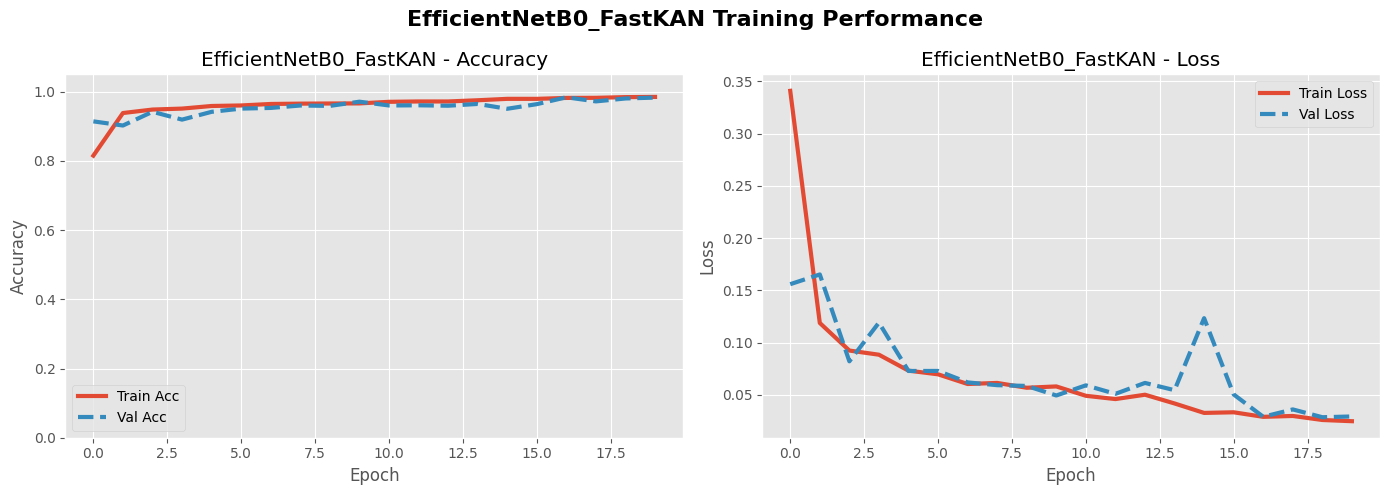

In [36]:
# Cell 13: Plot training curves

plt.style.use("ggplot")

hist = history_effb0_fastkan
model_name = "EfficientNetB0_FastKAN"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist["accuracy"], label="Train Acc", linewidth=3)
axes[0].plot(hist["val_accuracy"], label="Val Acc", linewidth=3, linestyle="--")
axes[0].set_title(f"{model_name} - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist["loss"], label="Train Loss", linewidth=3)
axes[1].plot(hist["val_loss"], label="Val Loss", linewidth=3, linestyle="--")
axes[1].set_title(f"{model_name} - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"{model_name} Training Performance", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "/kaggle/working/efficientnetb0_fastkan_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

/tmp/ipykernel_34/227521660.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)


EfficientNetB0_FastKAN Test Performance
Accuracy : 98.32%
Precision: 98.37%
Recall   : 98.32%
F1-score : 98.32%

Classification Report:
                      precision    recall  f1-score   support

           notdrowsy     0.9966    0.9666    0.9814      4574
   sleepyCombination     0.9940    0.9992    0.9966      2664
slowBlinkWithNodding     0.9468    0.9965    0.9710      1412
             yawning     0.9579    0.9940    0.9756      1329

            accuracy                         0.9832      9979
           macro avg     0.9739    0.9891    0.9812      9979
        weighted avg     0.9837    0.9832    0.9832      9979



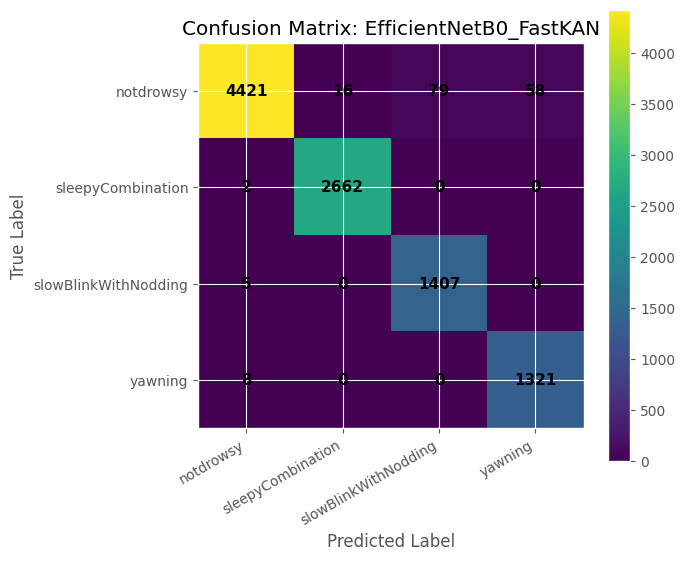

In [42]:
# Cell 14: Evaluate on test set

best_model_path = "./models/best_EfficientNetB0_FastKAN.pth"

checkpoint = torch.load(best_model_path, map_location=device)

model_effb0_fastkan = EfficientNetB0_FastKAN(
    num_classes=NUM_CLASSES,
    pretrained=False
).to(device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model_effb0_fastkan.load_state_dict(checkpoint["model_state_dict"])
else:
    model_effb0_fastkan.load_state_dict(checkpoint)

model_effb0_fastkan.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_effb0_fastkan(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0) * 100
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0) * 100
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0) * 100

print("EfficientNetB0_FastKAN Test Performance")
print("=" * 50)
print(f"Accuracy : {acc:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall   : {recall:.2f}%")
print(f"F1-score : {f1:.2f}%")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix: EfficientNetB0_FastKAN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=30, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar()
plt.tight_layout()
plt.savefig(
    "/kaggle/working/efficientnetb0_fastkan_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [51]:
# Cell 14: Evaluate on test set

best_model_path = "./models/best_EfficientNetB0_FastKAN.pth"

checkpoint = torch.load(best_model_path, map_location=device)

model_effb0_fastkan = EfficientNetB0_FastKAN(
    num_classes=NUM_CLASSES,
    pretrained=False
).to(device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model_effb0_fastkan.load_state_dict(checkpoint["model_state_dict"])
else:
    model_effb0_fastkan.load_state_dict(checkpoint)

model_effb0_fastkan.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_effb0_fastkan(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0) * 100
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0) * 100
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0) * 100

print("EfficientNetB0_FastKAN Test Performance")
print("=" * 50)
print(f"Accuracy : {acc:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall   : {recall:.2f}%")
print(f"F1-score : {f1:.2f}%")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))

/tmp/ipykernel_34/1083394095.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)


EfficientNetB0_FastKAN Test Performance
Accuracy : 98.32%
Precision: 98.37%
Recall   : 98.32%
F1-score : 98.32%

Classification Report:
                      precision    recall  f1-score   support

           notdrowsy     0.9966    0.9666    0.9814      4574
   sleepyCombination     0.9940    0.9992    0.9966      2664
slowBlinkWithNodding     0.9468    0.9965    0.9710      1412
             yawning     0.9579    0.9940    0.9756      1329

            accuracy                         0.9832      9979
           macro avg     0.9739    0.9891    0.9812      9979
        weighted avg     0.9837    0.9832    0.9832      9979



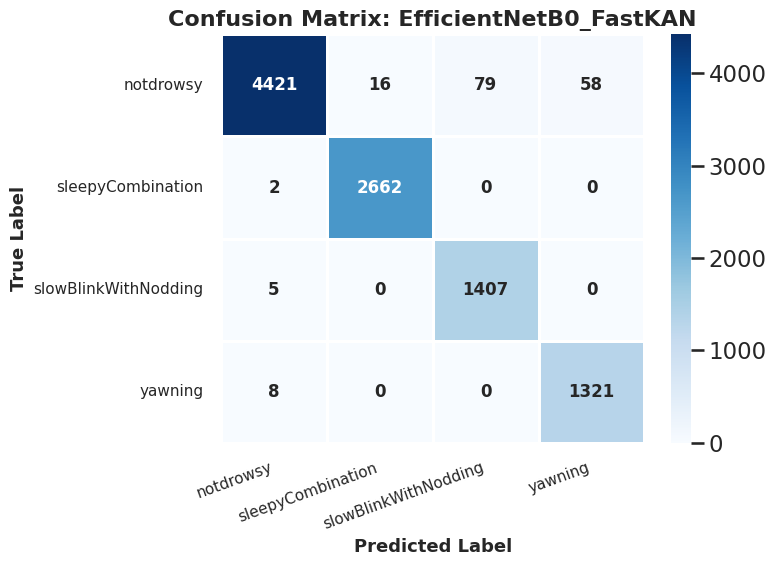

In [50]:
#Cell 15: Confusion Matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",   # xanh dương
    cbar=True,
    linewidths=1,
    linecolor="white",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title(
    "Confusion Matrix: EfficientNetB0_FastKAN",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=20, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/efficientnetb0_fastkan_confusion_matrix_beautiful.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# Cell 16: Save model to Kaggle working output

from pathlib import Path
import shutil

best_src = Path("./models/best_EfficientNetB0_FastKAN.pth")
last_src = Path("./models/last_EfficientNetB0_FastKAN.pth")

if best_src.exists():
    shutil.copy2(best_src, "/kaggle/working/best_EfficientNetB0_FastKAN.pth")
    print("Saved:", "/kaggle/working/best_EfficientNetB0_FastKAN.pth")
else:
    print("Not found:", best_src)

if last_src.exists():
    shutil.copy2(last_src, "/kaggle/working/last_EfficientNetB0_FastKAN.pth")
    print("Saved:", "/kaggle/working/last_EfficientNetB0_FastKAN.pth")
else:
    print("Not found:", last_src)

Saved: /kaggle/working/best_EfficientNetB0_FastKAN.pth
Saved: /kaggle/working/last_EfficientNetB0_FastKAN.pth
